# Fig S4 — Discovery and validation Cox supplements (univariable, KM sensitivity, multivariable IPI, LRT partition)

Execute cells in order.

Set `DLBCL_DATA_DIR` before the setup cell to override the data root.
Example: `DLBCL_DATA_DIR = '/path/to/data'`

In [1]:
%matplotlib inline

import os
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd().resolve()
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from dlbcl.notebook_setup import run_notebook_setup

_ctx = run_notebook_setup('validation_and_discovery', 'supplemental_fig4')
REPO_ROOT = _ctx.repo_root
_paths = _ctx.paths
FIG_DIR = _ctx.fig_dir
adata = _ctx.adata
arch_df = _ctx.arch_df
pred = _ctx.pred
gep = _ctx.gep
surv = _ctx.surv
archetype_label = _ctx.archetype_label
PATIENT_SUBSET = _ctx.patient_subset
OUTDIR = FIG_DIR
OUTDIR.mkdir(parents=True, exist_ok=True)

# Override data root: export DLBCL_DATA_DIR=/path/to/data before running.
print(f"AnnData: {_paths.adata_path}")
print(f"Figures: {FIG_DIR}")

import gc

import pandas as pd
import scanpy as sc

ADATA_PATH = _paths.adata_path

from IPython.display import display
from dlbcl.dlbcl_io import log_wrote, log_saved, rel_path, write_supplementary_table
subset = None  # nb8 classifier associations: filtered AnnData or None for all patients

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from dlbcl.dlbcl_io import log_wrote, log_saved, write_supplementary_table, rel_path
import dlbcl.validation_figures as vf

plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["font.family"] = "DejaVu Sans"

import scanpy as sc

import dlbcl.validation_cox as vc

from dlbcl.dlbcl_io import log_wrote, log_saved, write_supplementary_table
import dlbcl.validation_figures as vf
from dlbcl.km_sensitivity import (
    DISCOVERY_ARCHETYPE_OUTLIERS,
    DISCOVERY_ENDPOINTS,
    VALIDATION_EXCLUDE_LOCATIONS,
    build_discovery_km_survival_table,
    discovery_to_km_frame,
    exclude_locations,
    exclude_patients,
    load_validation_survival_table,
)


AnnData: /Users/troynoordenbos/code/public_repo/DLBCL_location_2026/data/DLBCL_location_2026.h5ad
Figures: /Users/troynoordenbos/code/public_repo/DLBCL_location_2026/figures/supplemental_fig4


## Fig S4 — panel overview

Panels follow manuscript order (S4A → S4B → S4C → S4D → S4E → S4F).

| Panel | Description |
|-------|-------------|
| S4A | Discovery univariable Cox — OS (curative intent) |
| S4B | Validation OS KM by archetype (PCNS / brain tumors excluded) |
| S4C | Validation multivariable Cox — archetype + IPI (exclude PCNSL; PCNSL coded as IPI >3) |
| S4D | Discovery OS 2-year landmark event rate (Location × Archetype) |
| S4E | Discovery symmetric likelihood-ratio tests (Location vs Archetype) |
| S4F | Discovery prognostic-information partition (shared vs unique χ²) |

**Data:** `data/DLBCL_location_2026.h5ad` — embedded `uns` tables supply discovery and validation cohort metadata.

In [2]:
# Discovery Cox constants (from nb9; paths come from the setup cell).
OUTDIR = FIG_DIR / "cox_clinical"
OUTDIR.mkdir(parents=True, exist_ok=True)
ADATA_PATH = _paths.adata_path

# --- Config ---
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

TIME_COL = "OS_time_JV"
ENDPOINTS = {
    "OS": "OS_status_JV",              # primary — any death
    "DSS": "OS_specific_status_JV",    # secondary — lymphoma-related death
}

REF_LOCATION = "bone"
REF_ARCHETYPE = "complex immune"

ARCHETYPE_ORDER = ["low immune", "cytotoxic predominant", "complex immune"]

FDR_BUCKET_THRESHOLDS = (0.001, 0.01, 0.05)


def _benjamini_hochberg(p_values):
    p = np.asarray(p_values, dtype=float)
    n = len(p)
    if n == 0:
        return np.array([])
    order = np.argsort(p)
    ranked = p[order]
    q_ranked = ranked * n / (np.arange(1, n + 1))
    q_ranked = np.minimum.accumulate(q_ranked[::-1])[::-1]
    q_ranked = np.clip(q_ranked, 0, 1)
    q = np.empty_like(q_ranked)
    q[order] = q_ranked
    return q


def _bucket_fdr(fdr):
    if not np.isfinite(fdr):
        return ""
    for thresh in FDR_BUCKET_THRESHOLDS:
        if fdr < thresh:
            return f"<{thresh:g}"
    return f"{fdr:.2f}"


def _add_fdr_column(plot_df):
    df = plot_df.copy()
    mask = (~df.get("is_reference", pd.Series(False, index=df.index)).fillna(False)) & df["p"].notna()
    fdr = np.full(len(df), np.nan)
    if mask.any():
        fdr[mask.to_numpy()] = _benjamini_hochberg(df.loc[mask, "p"].to_numpy())
    df["FDR"] = fdr
    return df


def _annotate_forest_fdr(ax, plot_df, y_positions):
    finite_upper = plot_df["CI_upper"].replace([np.inf, -np.inf], np.nan).dropna()
    x_label = float(finite_upper.max()) * 1.08 if len(finite_upper) else 3.0
    x_label = max(x_label, 1.05)
    for yi, (_, row) in zip(y_positions, plot_df.iterrows()):
        if row.get("is_reference"):
            continue
        label = _bucket_fdr(row.get("FDR", np.nan))
        if not label:
            continue
        ax.text(
            x_label,
            yi,
            label,
            ha="left",
            va="center",
            fontsize=7,
            color="0.35",
        )
    cur_lo, cur_hi = ax.get_xlim()
    ax.set_xlim(cur_lo, max(cur_hi, x_label * 1.18))

REF_COO = "GCB"
REF_DLBCLASS = "C4"

PENALIZER = 0.01

mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["font.family"] = "DejaVu Sans"

In [3]:
# Discovery Cox uses filtered IMC cells + embedded patient tables in adata.uns.
import gc

mask = (
    adata.obs["patient_id"].isin(PATIENT_SUBSET)
    & (adata.obs["filtering_status"] == "Unfiltered")
)
adata = adata[mask].copy()
gc.collect()
cluster_dict = dict(
    zip(arch_df["patient_id"].astype(str), arch_df["abundance_cluster_30"].astype(int))
)
adata.uns["abundance_cluster_30"] = cluster_dict
print(f"Cox discovery cells: {adata.n_obs:,} | patients: {adata.obs['patient_id'].nunique()}")


Cox discovery cells: 1,192,844 | patients: 64


## Discovery Cox — build survival table

Assembles the curative-intent discovery `surv` frame from embedded `adata.uns` patient tables (required for S4A and S4D–F).

In [4]:
ARCHETYPE_NAME_MAP = {
    1: "low immune",
    2: "cytotoxic predominant",
    3: "complex immune",
}

LOCATION_RECODE = {
    "pBONE": "bone",
    "polyOST": "bone",
    "disseminated": "bone",
}


def _patient_frame(uns_key: str) -> pd.DataFrame:
    df = pd.DataFrame(adata.uns[uns_key]).copy()
    if "patient_id" not in df.columns:
        df = df.reset_index(names="patient_id")
    df["patient_id"] = df["patient_id"].astype(str)
    return df.set_index("patient_id")


def _set_reference(series: pd.Series, reference) -> pd.Categorical:
    levels = [reference] + sorted([x for x in pd.Series(series).dropna().unique() if x != reference])
    return pd.Categorical(series, categories=levels, ordered=False)


def _set_ordered_categorical(series: pd.Series, order: list[str], reference: str) -> pd.Categorical:
    present = set(pd.Series(series).dropna().unique())
    levels = [reference] + [x for x in order if x != reference and x in present]
    levels.extend(sorted(present - set(levels)))
    return pd.Categorical(series, categories=levels, ordered=False)


clinical = _patient_frame("case_clinical")
classif = _patient_frame("case_classifications")
path = _patient_frame("case_path")

clinical["Curative_intent"] = pd.to_numeric(clinical["Curative_intent"], errors="coerce")
event_cols = list(ENDPOINTS.values())
surv = clinical.loc[clinical["Curative_intent"] == 1, [TIME_COL, *event_cols]].copy()

surv["Location"] = classif["Location"].replace(LOCATION_RECODE)
surv["COO"] = classif["COO_NanoString"]
surv["DLBclass"] = classif["DLBclass"].astype(str)

# Pathology HLA: source 0/1 = retained/intact → 1 = aberrant (loss)
surv["HLA_ABC"] = 1 - pd.to_numeric(path["HLAABC"], errors="coerce")
surv["HLA_DR"] = 1 - pd.to_numeric(path["HLADR"], errors="coerce")
surv["Age"] = pd.to_numeric(clinical["Age"], errors="coerce")
surv["Gender"] = pd.to_numeric(clinical["Gender"], errors="coerce")
# Univariable Sex: 0=female, 1=male (HR>1 = higher hazard in males in this cohort)
surv["Sex"] = surv["Gender"]
surv["IPI"] = pd.to_numeric(clinical["IPI/IELSG"], errors="coerce")

arch = pd.Series(cluster_dict, name="archetype_id")
surv["archetype_id"] = arch
surv["Archetype"] = surv["archetype_id"].map(ARCHETYPE_NAME_MAP)

for col in [TIME_COL, *event_cols, "HLA_ABC", "HLA_DR", "Age", "Gender", "IPI"]:
    surv[col] = pd.to_numeric(surv[col], errors="coerce")

surv = surv.dropna(subset=[TIME_COL, *event_cols, "Location", "Archetype", "COO", "DLBclass"])
surv = surv.loc[~surv["HLA_ABC"].isna() & ~surv["HLA_DR"].isna()]

surv["Location"] = _set_reference(surv["Location"], REF_LOCATION)
surv["Archetype"] = _set_ordered_categorical(surv["Archetype"], ARCHETYPE_ORDER, REF_ARCHETYPE)
surv["COO"] = _set_reference(surv["COO"], REF_COO)
surv["DLBclass"] = _set_reference(surv["DLBclass"], REF_DLBCLASS)

print(f"Curative-intent cohort: n={len(surv)}")
for ep_name, ep_col in ENDPOINTS.items():
    print(f"  {ep_name}: {int(surv[ep_col].sum())} events")
print("Reference levels:", REF_LOCATION, REF_ARCHETYPE, REF_COO, REF_DLBCLASS)
surv.to_csv(OUTDIR / "cox_clinical_survival_table.csv")
display(surv.head())

Curative-intent cohort: n=58
  OS: 25 events
  DSS: 20 events
Reference levels: bone complex immune GCB C4


,OS_time_JV,OS_status_JV,OS_specific_status_JV,Location,COO,DLBclass,HLA_ABC,HLA_DR,Age,Gender,Sex,IPI,archetype_id,Archetype
patient_id,,,,,,,,,,,,,,
T1,0.114990,1,1,PCNS,ABC,C5,1.0,1,73,1,1,3.0,2,cytotoxic predominant
T2,10.151951,0,0,PCNS,GCB,C5,0.0,0,66,0,0,2.0,2,cytotoxic predominant
T3,4.394251,1,1,PCNS,ABC,C4,1.0,1,70,1,1,3.0,2,cytotoxic predominant
T6,0.410678,1,1,PCNS,ABC,C5,1.0,1,66,0,0,2.0,1,low immune
T7,4.240931,0,0,PCNS,GCB,C5,0.0,0,70,0,0,NaN,3,complex immune


## Fig S4A — discovery univariable Cox (OS, curative intent)

Forest plot of univariable Cox models for clinical and biological covariates (Age, Sex, IPI, Location, Archetype, HLA class I/II, COO, DLBclass). Reference levels are shown at HR = 1.


ENDPOINT: OS  |  events = 25 / n = 58
Saved: data/supplementary/supplemental_fig4/figS4A_cox_univar_OS.csv


,endpoint,factor,term,n_patients,n_events,HR,CI_lower,CI_upper,coef,p
0,OS,Age,Age,58,25,1.075714,1.036137,1.116803,0.072985,0.000136
7,OS,Archetype,Archetype_cytotoxic predominant,58,25,5.100326,1.712624,15.189162,1.629304,0.003430
6,OS,Archetype,Archetype_low immune,58,25,2.347712,0.779639,7.069624,0.853441,0.129169
10,OS,COO,COO_ABC,58,25,6.362799,2.527023,16.020914,1.850468,0.000086
11,OS,COO,COO_Intermediate,58,25,6.229864,2.118807,18.317479,1.829355,0.000886
15,OS,DLBclass,DLBclass_C5,58,25,5.376051,1.150220,25.127291,1.681954,0.032529
13,OS,DLBclass,DLBclass_C1,58,25,5.216010,0.918416,29.623578,1.651733,0.062332
14,OS,DLBclass,DLBclass_C3,58,25,2.915465,0.585516,14.517002,1.070029,0.191402
9,OS,HLA-ABC,HLA_ABC,58,25,1.560692,0.680991,3.576788,0.445129,0.292813
8,OS,HLA-DR,HLA_DR,58,25,2.600066,1.185101,5.704445,0.955537,0.017144


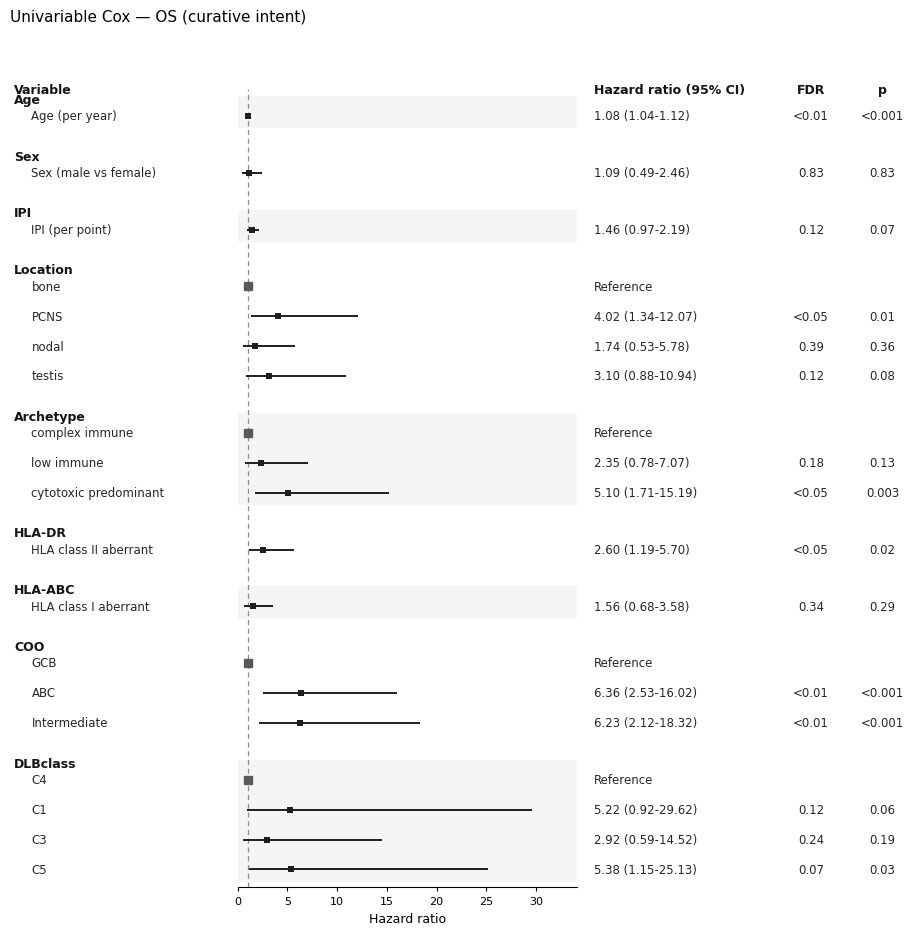

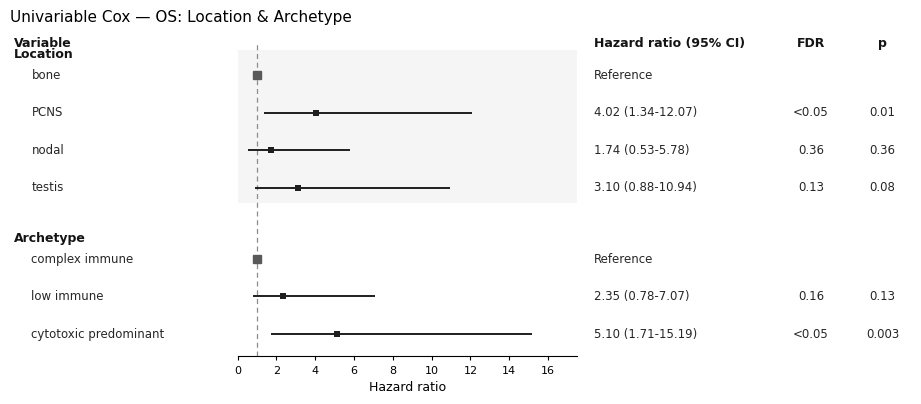


Multivariable (OS) — concordance 0.699


,coef,HR,CI_lower,CI_upper,p
covariate,,,,,
Location_PCNS,0.928707,2.531234,0.761126,8.417983,0.129833
Location_nodal,0.495126,1.640705,0.485092,5.549284,0.425809
Location_testis,0.828639,2.290201,0.583310,8.991821,0.235034
Archetype_low immune,0.482875,1.620727,0.477492,5.501154,0.438677
Archetype_cytotoxic predominant,1.228985,3.417758,1.001484,11.663761,0.049724


,endpoint,model_reduced,model_full,n_patients,n_events,loglik_reduced,loglik_full,lr_statistic,df,p_value
0,OS,Location,Location + Archetype,58,25,-89.428226,-87.079853,4.696745,2,0.095524


LRT (OS): Location + Archetype vs Location only — χ²(2) = 4.697, p = 0.09552

Stratified (OS) — concordance 0.596


/Users/troynoordenbos/code/public_repo/DLBCL_location_2026/.venv/lib/python3.14/site-packages/lifelines/fitters/__init__.py:1284: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for stratum, df_ in df.groupby(strata):
/Users/troynoordenbos/code/public_repo/DLBCL_location_2026/.venv/lib/python3.14/site-packages/lifelines/fitters/coxph_fitter.py:1868: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for stratum, stratified_X in X.groupby(self.strata):
/Users/troynoordenbos/code/public_repo/DLBCL_location_2026/.venv/lib/python3.14/site-packages/lifelines/fitters/coxph_fitter.py:1868: FutureWarning: The default of obs

,coef,HR,CI_lower,CI_upper,p
covariate,,,,,
Archetype_low immune,0.476991,1.611220,0.464323,5.591001,0.452403
Archetype_cytotoxic predominant,1.119520,3.063385,0.889281,10.552708,0.076060


Schoenfeld PH test (OS, multivariable Location + Archetype):


,endpoint,test_statistic,p,-log2(p)
Archetype_cytotoxic predominant,OS,0.084791,0.770907,0.375371
Archetype_low immune,OS,0.683818,0.408275,1.292386
Location_PCNS,OS,0.114670,0.734888,0.444403
Location_nodal,OS,0.044312,0.833275,0.263136
Location_testis,OS,0.046756,0.828807,0.270892



ENDPOINT: DSS  |  events = 20 / n = 58
Saved: data/supplementary/supplemental_fig4/figS4A_cox_univar_DSS.csv


,endpoint,factor,term,n_patients,n_events,HR,CI_lower,CI_upper,coef,p
0,DSS,Age,Age,58,20,1.081824,1.036373,1.129270,0.078649,0.000329
7,DSS,Archetype,Archetype_cytotoxic predominant,58,20,5.999949,1.791777,20.091449,1.791751,0.003663
6,DSS,Archetype,Archetype_low immune,58,20,2.170932,0.612856,7.690143,0.775157,0.229667
11,DSS,COO,COO_Intermediate,58,20,8.541117,2.707716,26.941777,2.144892,0.000253
10,DSS,COO,COO_ABC,58,20,7.294806,2.486005,21.405508,1.987163,0.000297
15,DSS,DLBclass,DLBclass_C5,58,20,4.661511,0.950399,22.863760,1.539340,0.057793
14,DSS,DLBclass,DLBclass_C3,58,20,2.537609,0.483556,13.316876,0.931222,0.270919
13,DSS,DLBclass,DLBclass_C1,58,20,2.613801,0.354158,19.290714,0.960805,0.346127
9,DSS,HLA-ABC,HLA_ABC,58,20,1.700980,0.665056,4.350512,0.531205,0.267571
8,DSS,HLA-DR,HLA_DR,58,20,2.857803,1.188246,6.873186,1.050053,0.019018


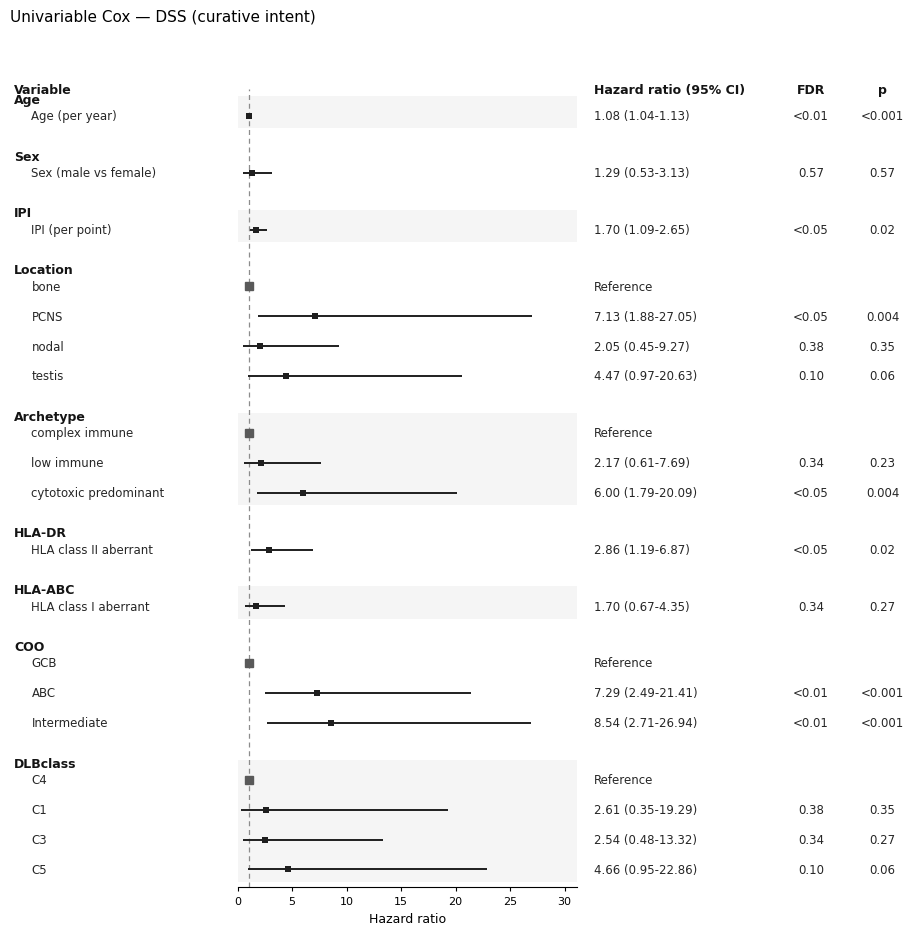

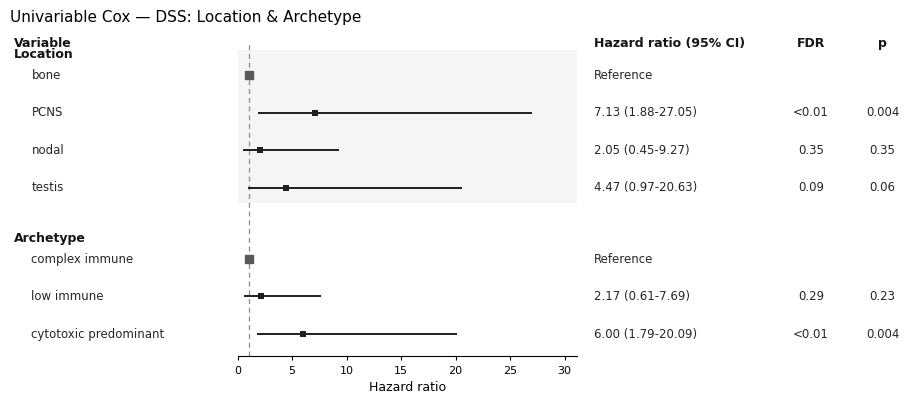


Multivariable (DSS) — concordance 0.750


,coef,HR,CI_lower,CI_upper,p
covariate,,,,,
Location_PCNS,1.595831,4.932425,1.131931,21.493201,0.033588
Location_nodal,0.711285,2.036607,0.440169,9.423130,0.362795
Location_testis,1.344358,3.835723,0.719803,20.439998,0.115297
Archetype_low immune,0.134029,1.143426,0.273243,4.784835,0.854391
Archetype_cytotoxic predominant,1.068604,2.911313,0.714443,11.863422,0.136001


,endpoint,model_reduced,model_full,n_patients,n_events,loglik_reduced,loglik_full,lr_statistic,df,p_value
0,DSS,Location,Location + Archetype,58,20,-68.417702,-66.330738,4.173929,2,0.124063


LRT (DSS): Location + Archetype vs Location only — χ²(2) = 4.174, p = 0.1241

Stratified (DSS) — concordance 0.570


/Users/troynoordenbos/code/public_repo/DLBCL_location_2026/.venv/lib/python3.14/site-packages/lifelines/fitters/__init__.py:1284: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for stratum, df_ in df.groupby(strata):
/Users/troynoordenbos/code/public_repo/DLBCL_location_2026/.venv/lib/python3.14/site-packages/lifelines/fitters/coxph_fitter.py:1868: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for stratum, stratified_X in X.groupby(self.strata):
/Users/troynoordenbos/code/public_repo/DLBCL_location_2026/.venv/lib/python3.14/site-packages/lifelines/fitters/coxph_fitter.py:1868: FutureWarning: The default of obs

...


LRT comparison (OS vs DSS):


,endpoint,model_reduced,model_full,n_patients,n_events,loglik_reduced,loglik_full,lr_statistic,df,p_value
0,OS,Location,Location + Archetype,58,25,-89.428226,-87.079853,4.696745,2,0.095524
1,DSS,Location,Location + Archetype,58,20,-68.417702,-66.330738,4.173929,2,0.124063



Archetype HRs — multivariable and stratified models:


,endpoint,model,term,HR,CI_lower,CI_upper,p
0,OS,multivariable,Archetype_low immune,1.620727,0.477492,5.501154,0.438677
1,OS,multivariable,Archetype_cytotoxic predominant,3.417758,1.001484,11.663761,0.049724
2,OS,stratified,Archetype_low immune,1.611220,0.464323,5.591001,0.452403
3,OS,stratified,Archetype_cytotoxic predominant,3.063385,0.889281,10.552708,0.076060
4,DSS,multivariable,Archetype_low immune,1.143426,0.273243,4.784835,0.854391
5,DSS,multivariable,Archetype_cytotoxic predominant,2.911313,0.714443,11.863422,0.136001
6,DSS,stratified,Archetype_low immune,1.141918,0.261864,4.979593,0.859803
7,DSS,stratified,Archetype_cytotoxic predominant,2.509210,0.609783,10.325204,0.202443



Saved outputs to figures/supplemental_fig4/cox_clinical


In [5]:
# Sections 1–4: run for each survival endpoint (OS primary, DSS secondary)

from lifelines import CoxPHFitter

from lifelines.statistics import proportional_hazard_test

from scipy.stats import chi2



UNIVARIABLE_FACTORS = {

    "Age": "Age",

    "Sex": "Sex",

    "IPI": "IPI",

    "Location": "Location",

    "Archetype": "Archetype",

    "HLA-DR": "HLA_DR",

    "HLA-ABC": "HLA_ABC",

    "COO": "COO",

    "DLBclass": "DLBclass",

}



CONTINUOUS_COVARIATES = {"Age", "Sex", "IPI", "HLA_DR", "HLA_ABC"}



CONTINUOUS_LABELS = {

    "Age": "Age (per year)",

    "Sex": "Sex (male vs female)",

    "IPI": "IPI (per point)",

    "HLA-DR": "HLA class II aberrant",

    "HLA-ABC": "HLA class I aberrant",

}



# Categorical levels omitted from Cox models and forest plots.

CATEGORICAL_EXCLUDE_LEVELS = {

    "DLBclass": {"0"},

}





def _categorical_levels(col, reference):

    exclude = CATEGORICAL_EXCLUDE_LEVELS.get(col, set())

    return [lv for lv in surv[col].cat.categories if lv not in exclude]





UNIVARIATE_CATEGORICAL = {

    "Location": {"col": "Location", "reference": REF_LOCATION, "levels": _categorical_levels("Location", REF_LOCATION)},

    "Archetype": {"col": "Archetype", "reference": REF_ARCHETYPE, "levels": _categorical_levels("Archetype", REF_ARCHETYPE)},

    "COO": {"col": "COO", "reference": REF_COO, "levels": _categorical_levels("COO", REF_COO)},

    "DLBclass": {"col": "DLBclass", "reference": REF_DLBCLASS, "levels": _categorical_levels("DLBclass", REF_DLBCLASS)},

}



FACTOR_COLORS = {

    "Age": "0.25",

    "Sex": "0.25",

    "IPI": "0.25",

    "HLA-DR": "#984ea3",

    "HLA-ABC": "#984ea3",

    "Location": "#377eb8",

    "Archetype": "#e41a1c",

    "COO": "#4daf4a",

    "DLBclass": "#ff7f00",

}



GROUP_GAP = 0.8





def _design_matrix(df, col, event_col):

    if col in CONTINUOUS_COVARIATES:

        return df[[TIME_COL, event_col, col]].copy()

    out = df[[TIME_COL, event_col, col]].copy()

    dummies = pd.get_dummies(out[col], prefix=col, drop_first=True)

    return pd.concat([out[[TIME_COL, event_col]], dummies], axis=1)





def _extract_cox_terms(cph, factor_name):

    rows = []

    for term, row in cph.summary.iterrows():

        rows.append({

            "factor": factor_name,

            "term": term,

            "n_patients": int(cph.event_observed.shape[0]),

            "n_events": int(cph.event_observed.sum()),

            "HR": float(np.exp(row["coef"])),

            "CI_lower": float(np.exp(row["coef lower 95%"])),

            "CI_upper": float(np.exp(row["coef upper 95%"])),

            "coef": float(row["coef"]),

            "p": float(row["p"]),

        })

    return rows





def _expand_univariable_forest(uni_df, factors=None):

    """Group by factor; add reference-level rows for categorical dummies."""

    factor_order = [

        f for f in UNIVARIABLE_FACTORS if factors is None or f in factors

    ]

    rows = []

    for factor_label in factor_order:

        if factor_label in CONTINUOUS_LABELS:

            sub = uni_df[uni_df["factor"] == factor_label]

            if sub.empty:

                continue

            r = sub.iloc[0].to_dict()

            r["label"] = CONTINUOUS_LABELS[factor_label]

            r["is_reference"] = False

            rows.append(r)

            continue



        spec = UNIVARIATE_CATEGORICAL[factor_label]

        col = spec["col"]

        fac_mask = uni_df["factor"] == factor_label

        n_patients = int(uni_df.loc[fac_mask, "n_patients"].max()) if fac_mask.any() else np.nan

        n_events = int(uni_df.loc[fac_mask, "n_events"].max()) if fac_mask.any() else np.nan



        for level in spec["levels"]:

            if level in CATEGORICAL_EXCLUDE_LEVELS.get(factor_label, set()):

                continue

            term = f"{col}_{level}"

            is_ref = level == spec["reference"]

            match = uni_df[(uni_df["factor"] == factor_label) & (uni_df["term"] == term)]

            if is_ref:

                rows.append({

                    "factor": factor_label,

                    "term": term,

                    "label": str(level),

                    "n_patients": n_patients,

                    "n_events": n_events,

                    "HR": 1.0,

                    "CI_lower": 1.0,

                    "CI_upper": 1.0,

                    "coef": 0.0,

                    "p": np.nan,

                    "is_reference": True,

                })

            elif len(match):

                r = match.iloc[0].to_dict()

                r["label"] = str(level)

                r["is_reference"] = False

                rows.append(r)

    return pd.DataFrame(rows)





def _grouped_y_layout(plot_df, group_col="factor"):

    y_ticks, y_labels = [], []

    separators = []

    y = 0.0

    prev_group = None

    for _, row in plot_df.iterrows():

        if prev_group is not None and row[group_col] != prev_group:

            separators.append(y - GROUP_GAP / 2)

            y += GROUP_GAP

        if prev_group != row[group_col]:

            y_labels.append(f"{row[group_col]} — {row['label']}")

        else:

            y_labels.append(f"    {row['label']}")

        y_ticks.append(y)

        prev_group = row[group_col]

        y += 1.0

    return np.array(y_ticks), y_labels, separators





def _draw_forest_points(ax, plot_df, y_ticks):

    for yi, (_, row) in zip(y_ticks, plot_df.iterrows()):

        color = FACTOR_COLORS.get(row["factor"], "black")

        if row.get("is_reference"):

            ax.plot(1.0, yi, marker="s", color="0.45", markersize=6, linestyle="none", zorder=3)

            continue

        if not np.isfinite(row["HR"]):

            ax.plot(np.nan, yi, marker="x", color=color, markersize=6, linestyle="none")

            continue

        ax.errorbar(

            row["HR"], yi,

            xerr=[[row["HR"] - row["CI_lower"]], [row["CI_upper"] - row["HR"]]],

            fmt="o", color=color, ecolor=color, capsize=3, markersize=5,

        )





def _forest_plot(uni_df, endpoint_name, out_stem, *, factors=None, title=None):

    from dlbcl.cox_forest_plot import save_cox_forest_table



    plot_df = _expand_univariable_forest(

        uni_df.drop(columns=["endpoint"], errors="ignore"),

        factors=factors,

    )

    save_cox_forest_table(

        plot_df,

        OUTDIR / out_stem,

        title=title or f"Univariable Cox — {endpoint_name} (curative intent)",

        log_x=False,

        show=True,

    )





lrt_rows = []

key_term_rows = []



for endpoint_name, event_col in ENDPOINTS.items():

    print("\n" + "=" * 72)

    print(f"ENDPOINT: {endpoint_name}  |  events = {int(surv[event_col].sum())} / n = {len(surv)}")

    print("=" * 72)



    # --- 1. Univariable ---

    uni_rows = []

    for label, col in UNIVARIABLE_FACTORS.items():

        df = _design_matrix(surv, col, event_col)

        df = df.replace([np.inf, -np.inf], np.nan).dropna()

        cph = CoxPHFitter(penalizer=PENALIZER)

        cph.fit(df, duration_col=TIME_COL, event_col=event_col)

        uni_rows.extend(_extract_cox_terms(cph, label))



    uni_df = pd.DataFrame(uni_rows).sort_values(["factor", "p"])

    plot_exclude_terms = {

        f"{UNIVARIATE_CATEGORICAL[factor]['col']}_{lv}"

        for factor, levels in CATEGORICAL_EXCLUDE_LEVELS.items()

        for lv in levels

        if factor in UNIVARIATE_CATEGORICAL

    }

    uni_df = uni_df.loc[~uni_df["term"].isin(plot_exclude_terms)].copy()

    uni_df.insert(0, "endpoint", endpoint_name)

    uni_path = OUTDIR / f"cox_univariable_{endpoint_name}.csv"

    uni_df.to_csv(uni_path, index=False)

    log_saved(write_supplementary_table(uni_df, REPO_ROOT, f"figS4A_cox_univar_{endpoint_name}"), REPO_ROOT)

    if endpoint_name == "OS":

        uni_df.drop(columns=["endpoint"]).to_csv(OUTDIR / "cox_univariable.csv", index=False)

    display(uni_df)

    _forest_plot(uni_df, endpoint_name, f"cox_univariable_forest_{endpoint_name}")

    _forest_plot(

        uni_df,

        endpoint_name,

        f"cox_univariable_location_archetype_forest_{endpoint_name}",

        factors=("Location", "Archetype"),

        title=f"Univariable Cox — {endpoint_name}: Location & Archetype",

    )

    if endpoint_name == "OS":

        import shutil

        shutil.copy(OUTDIR / f"cox_univariable_forest_{endpoint_name}.svg", OUTDIR / "cox_univariable_forest.svg")

        shutil.copy(OUTDIR / f"cox_univariable_forest_{endpoint_name}.png", OUTDIR / "cox_univariable_forest.png")

        shutil.copy(

            OUTDIR / f"cox_univariable_location_archetype_forest_{endpoint_name}.svg",

            OUTDIR / "cox_univariable_location_archetype_forest.svg",

        )

        shutil.copy(

            OUTDIR / f"cox_univariable_location_archetype_forest_{endpoint_name}.png",

            OUTDIR / "cox_univariable_location_archetype_forest.png",

        )



    # --- 2. Multivariable Location + Archetype ---

    mv = surv[[TIME_COL, event_col, "Location", "Archetype"]].copy()

    mv = pd.get_dummies(mv, columns=["Location", "Archetype"], drop_first=True)

    mv = mv.replace([np.inf, -np.inf], np.nan).dropna()



    cph_mv = CoxPHFitter(penalizer=PENALIZER)

    cph_mv.fit(mv, duration_col=TIME_COL, event_col=event_col)



    mv_summary = cph_mv.summary.copy()

    mv_summary["HR"] = np.exp(mv_summary["coef"])

    mv_summary["CI_lower"] = np.exp(mv_summary["coef lower 95%"])

    mv_summary["CI_upper"] = np.exp(mv_summary["coef upper 95%"])

    mv_summary.insert(0, "endpoint", endpoint_name)

    mv_summary.to_csv(OUTDIR / f"cox_multivariable_location_archetype_{endpoint_name}.csv")

    if endpoint_name == "OS":

        mv_summary.to_csv(OUTDIR / "cox_multivariable_location_archetype.csv")

    print(f"\nMultivariable ({endpoint_name}) — concordance {cph_mv.concordance_index_:.3f}")

    display(mv_summary[["coef", "HR", "CI_lower", "CI_upper", "p"]])



    for term in mv_summary.index:

        if "Archetype" in term:

            key_term_rows.append({

                "endpoint": endpoint_name,

                "model": "multivariable",

                "term": term,

                "HR": float(mv_summary.loc[term, "HR"]),

                "CI_lower": float(mv_summary.loc[term, "CI_lower"]),

                "CI_upper": float(mv_summary.loc[term, "CI_upper"]),

                "p": float(mv_summary.loc[term, "p"]),

            })



    # --- 3. Likelihood-ratio test ---

    loc = surv[[TIME_COL, event_col, "Location"]].copy()

    loc = pd.get_dummies(loc, columns=["Location"], drop_first=True).dropna()

    arch = surv[[TIME_COL, event_col, "Location", "Archetype"]].copy()

    arch = pd.get_dummies(arch, columns=["Location", "Archetype"], drop_first=True).dropna()

    common_idx = loc.index.intersection(arch.index)

    loc = loc.loc[common_idx]

    arch = arch.loc[common_idx]



    cph_loc = CoxPHFitter(penalizer=PENALIZER).fit(loc, duration_col=TIME_COL, event_col=event_col)

    cph_arch = CoxPHFitter(penalizer=PENALIZER).fit(arch, duration_col=TIME_COL, event_col=event_col)



    lr_stat = 2 * (cph_arch.log_likelihood_ - cph_loc.log_likelihood_)

    df_diff = len(cph_arch.params_) - len(cph_loc.params_)

    lr_p = float(chi2.sf(lr_stat, df_diff))



    lrt_row = {

        "endpoint": endpoint_name,

        "model_reduced": "Location",

        "model_full": "Location + Archetype",

        "n_patients": len(common_idx),

        "n_events": int(arch[event_col].sum()),

        "loglik_reduced": float(cph_loc.log_likelihood_),

        "loglik_full": float(cph_arch.log_likelihood_),

        "lr_statistic": float(lr_stat),

        "df": int(df_diff),

        "p_value": lr_p,

    }

    lrt_rows.append(lrt_row)

    lrt_one = pd.DataFrame([lrt_row])

    lrt_one.to_csv(OUTDIR / f"cox_lrt_location_vs_location_archetype_{endpoint_name}.csv", index=False)

    if endpoint_name == "OS":

        lrt_one.to_csv(OUTDIR / "cox_lrt_location_vs_location_archetype.csv", index=False)

    display(lrt_one)

    print(

        f"LRT ({endpoint_name}): Location + Archetype vs Location only — "

        f"χ²({df_diff}) = {lr_stat:.3f}, p = {lr_p:.4g}"

    )



    # --- 4. Stratified Cox (location strata) ---

    strat_df = surv[[TIME_COL, event_col, "Location", "Archetype"]].copy()

    strat_df = pd.get_dummies(strat_df, columns=["Archetype"], drop_first=True)

    strat_df = strat_df.replace([np.inf, -np.inf], np.nan).dropna()



    cph_strat = CoxPHFitter(penalizer=PENALIZER)

    cph_strat.fit(

        strat_df,

        duration_col=TIME_COL,

        event_col=event_col,

        strata=["Location"],

    )



    strat_summary = cph_strat.summary.copy()

    strat_summary["HR"] = np.exp(strat_summary["coef"])

    strat_summary["CI_lower"] = np.exp(strat_summary["coef lower 95%"])

    strat_summary["CI_upper"] = np.exp(strat_summary["coef upper 95%"])

    strat_summary.insert(0, "endpoint", endpoint_name)

    strat_summary.to_csv(OUTDIR / f"cox_stratified_by_location_{endpoint_name}.csv")

    if endpoint_name == "OS":

        strat_summary.to_csv(OUTDIR / "cox_stratified_by_location.csv")

    print(f"\nStratified ({endpoint_name}) — concordance {cph_strat.concordance_index_:.3f}")

    display(strat_summary[["coef", "HR", "CI_lower", "CI_upper", "p"]])



    for term in strat_summary.index:

        if "Archetype" in term:

            key_term_rows.append({

                "endpoint": endpoint_name,

                "model": "stratified",

                "term": term,

                "HR": float(strat_summary.loc[term, "HR"]),

                "CI_lower": float(strat_summary.loc[term, "CI_lower"]),

                "CI_upper": float(strat_summary.loc[term, "CI_upper"]),

                "p": float(strat_summary.loc[term, "p"]),

            })



    # PH test on multivariable model

    ph_test = proportional_hazard_test(cph_mv, mv, time_transform="rank")

    ph_df = ph_test.summary.copy()

    ph_df.insert(0, "endpoint", endpoint_name)

    ph_df.to_csv(OUTDIR / f"cox_ph_test_location_archetype_{endpoint_name}.csv")

    if endpoint_name == "OS":

        ph_df.to_csv(OUTDIR / "cox_ph_test_location_archetype.csv")

    print(f"Schoenfeld PH test ({endpoint_name}, multivariable Location + Archetype):")

    display(ph_df)



# Combined summaries across endpoints

lrt_all = pd.DataFrame(lrt_rows)

lrt_all.to_csv(OUTDIR / "cox_lrt_location_vs_location_archetype_all_endpoints.csv", index=False)

print("\nLRT comparison (OS vs DSS):")

display(lrt_all)



key_terms = pd.DataFrame(key_term_rows)

key_terms.to_csv(OUTDIR / "cox_archetype_hr_os_vs_dss.csv", index=False)

print("\nArchetype HRs — multivariable and stratified models:")

display(key_terms)



print(f"\nSaved outputs to {rel_path(OUTDIR, REPO_ROOT)}")


## Fig S4B — validation OS KM (PCNS excluded)

Five-year overall survival by predicted immune archetype in the validation cohort after removing primary CNS / brain tumor cases.

Validation KM: n=308 -> 178 after excluding ('PCNS',)
Archetype
complex immune           87
low immune               54
cytotoxic predominant    37


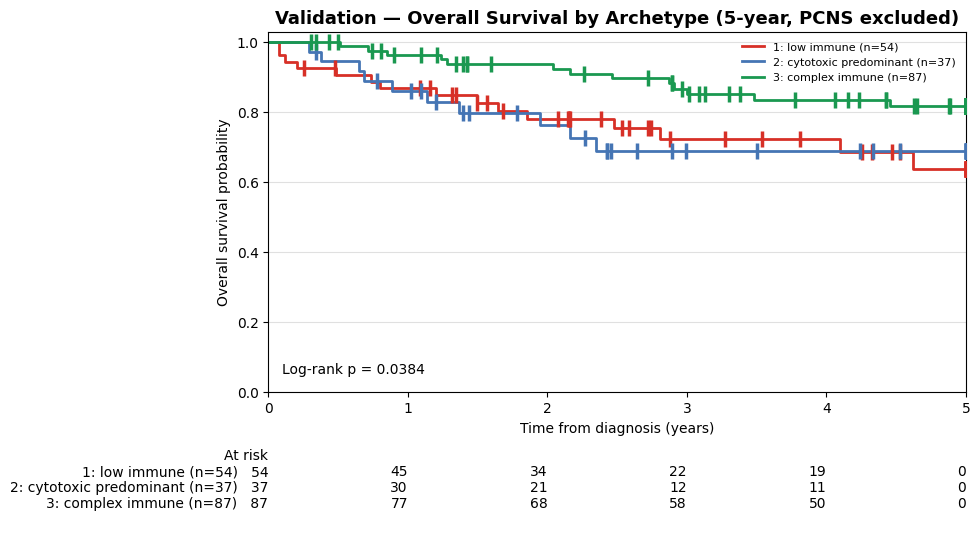

Wrote figures/supplemental_fig4/figS4B_val_km_os_archetype_no_pcns.svg
Saved: data/supplementary/supplemental_fig4/figS4B_val_km_os_archetype_no_pcns.csv


In [6]:
# adata loaded in setup cell
val_surv = load_validation_survival_table(adata)
val_no_pcns = exclude_locations(val_surv, VALIDATION_EXCLUDE_LOCATIONS)

print(f"Validation KM: n={len(val_surv)} -> {len(val_no_pcns)} after excluding {VALIDATION_EXCLUDE_LOCATIONS}")
print(val_no_pcns["Archetype"].value_counts().to_string())

arch_os = vf.plot_km_by_archetype(
    val_no_pcns,
    title="Validation — Overall Survival by Archetype (5-year, PCNS excluded)",
    ylabel="Overall survival probability",
    out_path=FIG_DIR / "figS4B_val_km_os_archetype_no_pcns.svg",
)
arch_os.to_csv(OUTDIR / "figS4B_val_km_os_archetype_no_pcns_summary.csv", index=False)
log_wrote(FIG_DIR / "figS4B_val_km_os_archetype_no_pcns.svg", REPO_ROOT)
log_saved(
    write_supplementary_table(arch_os, REPO_ROOT, "figS4B_val_km_os_archetype_no_pcns"),
    REPO_ROOT,
)

## Fig S4C — validation multivariable Cox (Archetype + IPI)

Two OS models adjusting for immune archetype and IPI (reference: complex immune; IPI 0–1 vs >3):

1. **Exclude PCNSL** — non-CNS patients only (patients without recorded IPI excluded).
2. **Include PCNSL with IPI >3** — all non-PCNSL patients plus PCNSL assigned to IPI >3 (IELSG high-risk proxy when score missing).

In [7]:
COX_DIR = OUTDIR / "cox_validation"
COX_DIR.mkdir(parents=True, exist_ok=True)


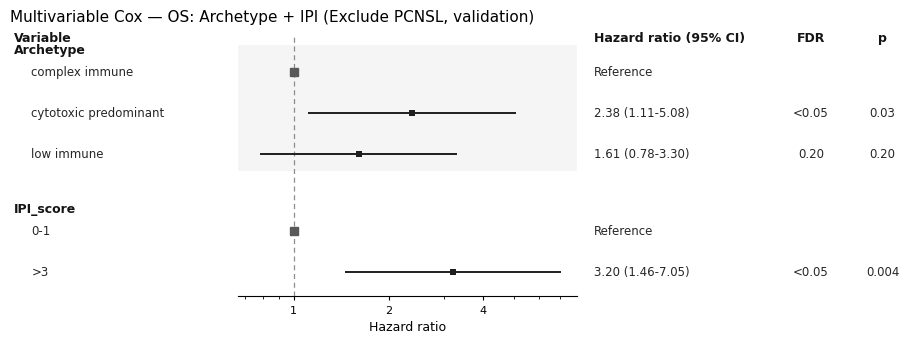

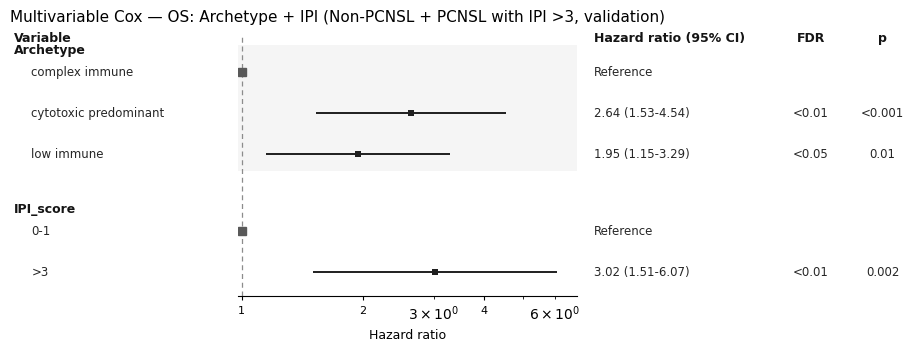

Exclude PCNSL: n=149 | OS events=42


,coef,HR,CI_lower,CI_upper,p
covariate,,,,,
Archetype_cytotoxic predominant,0.865010,2.375030,1.111257,5.076024,0.025602
Archetype_low immune,0.474225,1.606769,0.781480,3.303611,0.197222
IPI_score_>3,1.164201,3.203361,1.455288,7.051200,0.003828


Non-PCNSL + PCNSL with IPI >3: n=279 | OS events=107


,coef,HR,CI_lower,CI_upper,p
covariate,,,,,
Archetype_cytotoxic predominant,0.968980,2.635254,1.528791,4.542522,0.000487
Archetype_low immune,0.665815,1.946077,1.149467,3.294756,0.013193
IPI_score_>3,1.106481,3.023701,1.507260,6.065818,0.001839


In [8]:
archetype_ipi_results = vc.run_archetype_ipi_cox_models(pred, COX_DIR, show=True)

for key, model in archetype_ipi_results["models"].items():
    print(
        f"{model['label']}: n={model['n_patients']} | "
        f"OS events={model['n_events']}"
    )
    display(model["summary"][["coef", "HR", "CI_lower", "CI_upper", "p"]])

## Fig S4D — discovery OS 2-year landmark event rate (Location × Archetype)

Empirical event-rate grid for the curative-intent discovery cohort. Cell fill reflects the landmark event rate; opacity scales with at-risk **n** (α = 0.1 at n = 1, α = 1.0 at n ≥ 7).

## Fig S4E — symmetric likelihood-ratio tests (discovery OS)

Likelihood-ratio χ² for nested Cox models comparing null, Location-only, Archetype-only, and joint specifications (includes the omnibus Null → Location + Archetype test).

## Fig S4F — prognostic information partition (discovery OS)

Decomposes the joint Location + Archetype LR χ² into unique Location, shared, and unique Archetype components (stacked bar; total matches the Fig S4E omnibus).

Likelihood partition (χ² units):


,chi2_total,chi2_unique_location,chi2_unique_archetype,chi2_shared_raw,chi2_shared,shared_suppression,endpoint
0,12.327,2.682,4.697,4.948,4.948,False,OS
1,15.887,5.832,4.174,5.881,5.881,False,DSS



Symmetric LRTs:


,endpoint,model_reduced,model_full,n_patients,n_events,lr_statistic,df,p_value
0,OS,Null,Location,58,25,7.630,3,0.0543
1,OS,Null,Archetype,58,25,9.645,2,0.0080
2,OS,Null,Location + Archetype,58,25,12.327,5,0.0306
3,OS,Location,Location + Archetype,58,25,4.697,2,0.0955
4,OS,Archetype,Location + Archetype,58,25,2.682,3,0.4434
5,DSS,Null,Location,58,20,11.713,3,0.0084
6,DSS,Null,Archetype,58,20,10.055,2,0.0066
7,DSS,Null,Location + Archetype,58,20,15.887,5,0.0072
8,DSS,Location,Location + Archetype,58,20,4.174,2,0.1241
9,DSS,Archetype,Location + Archetype,58,20,5.832,3,0.1201


Saved: data/supplementary/supplemental_fig4/figS4E_symmetric_lrt.csv
Saved: data/supplementary/supplemental_fig4/figS4F_loglikelihood_partition.csv
Saved: figures/supplemental_fig4/cox_clinical/cox_location_archetype_symmetric_lrt_OS.svg


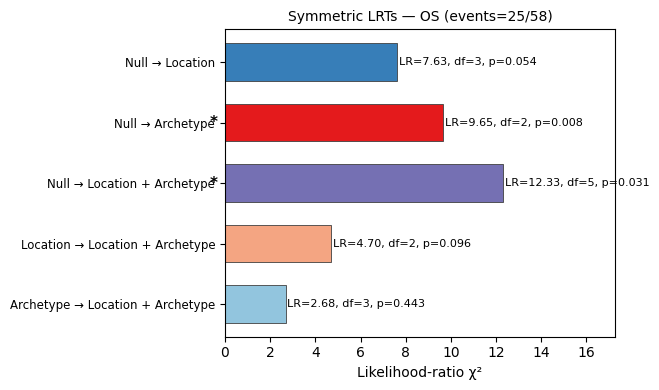

Saved: figures/supplemental_fig4/cox_clinical/cox_location_archetype_symmetric_lrt_DSS.svg


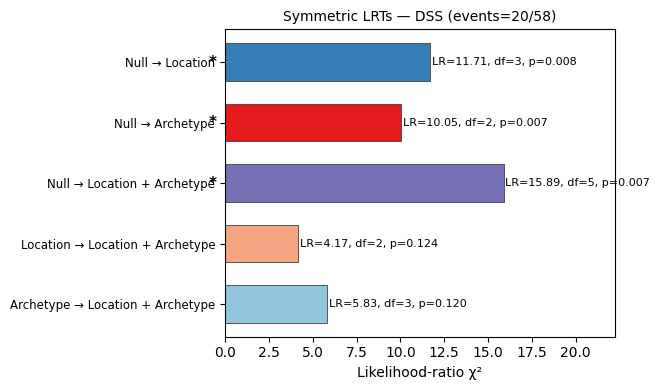

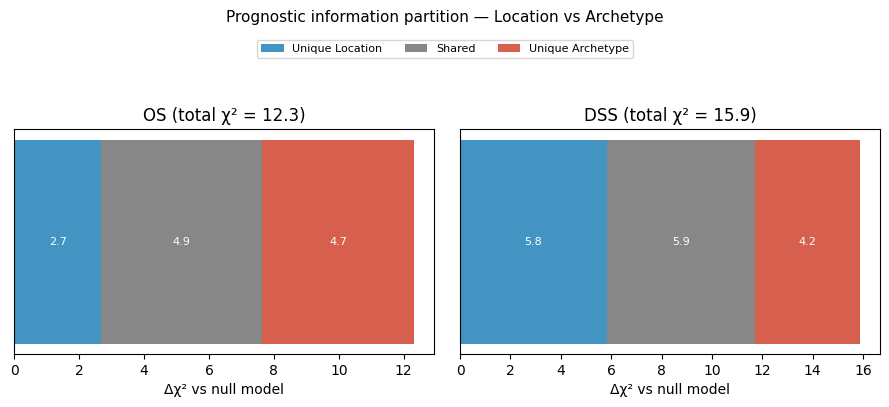

Saved: data/supplementary/supplemental_fig4/figS4D_event_rate_grid.csv


/var/folders/k_/ffwscldj7gx7ch29c5ffhr4c0000gn/T/ipykernel_61660/3999439179.py:541: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_g.tight_layout()


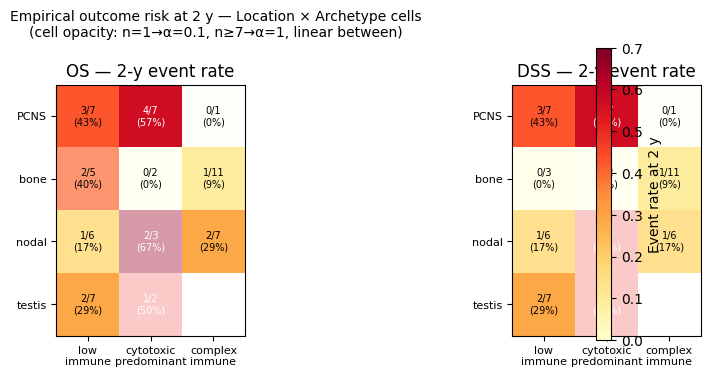


Saved decomposition figures to figures/supplemental_fig4/cox_clinical


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter
from scipy.stats import chi2


def _cox_design(surv_df, event_col, factors=()):
    """Build Cox design matrix for null / Location / Archetype / both."""
    cols = [TIME_COL, event_col, *factors]
    df = surv_df[cols].copy().replace([np.inf, -np.inf], np.nan).dropna()

    if not factors:
        return df

    return pd.get_dummies(df, columns=list(factors), drop_first=True)


def _fit_cox(df, event_col):
    cph = CoxPHFitter(penalizer=PENALIZER)
    cph.fit(df, duration_col=TIME_COL, event_col=event_col)
    return cph


def _lrt_row(endpoint, reduced_label, full_label, cph_reduced, cph_full, n_events):
    lr = 2 * (cph_full.log_likelihood_ - cph_reduced.log_likelihood_)
    df_diff = len(cph_full.params_) - len(cph_reduced.params_)

    return {
        "endpoint": endpoint,
        "model_reduced": reduced_label,
        "model_full": full_label,
        "n_patients": int(cph_full.event_observed.shape[0]),
        "n_events": int(n_events),
        "lr_statistic": float(lr),
        "df": int(df_diff),
        "p_value": float(chi2.sf(lr, df_diff)),
    }


def _partition_loglik(ll_null, ll_loc, ll_arch, ll_full):
    """
    Partition Cox likelihood-ratio χ² into:
      - unique Location contribution
      - unique Archetype contribution
      - shared contribution

    Note:
    This is likelihood-ratio χ² partitioning, not literal variance explained.
    """
    total = 2 * (ll_full - ll_null)
    unique_loc = 2 * (ll_full - ll_arch)
    unique_arch = 2 * (ll_full - ll_loc)
    shared_raw = 2 * (ll_loc + ll_arch - ll_full - ll_null)

    shared = max(0.0, float(shared_raw))

    return {
        "chi2_total": float(total),
        "chi2_unique_location": float(unique_loc),
        "chi2_unique_archetype": float(unique_arch),
        "chi2_shared_raw": float(shared_raw),
        "chi2_shared": shared,
        "shared_suppression": bool(shared_raw < 0),
    }


# ------------------------------------------------------------
# Fit models and collect LRT / partition results
# ------------------------------------------------------------

partition_rows = []
lrt_sym_rows = []

for endpoint_name, event_col in ENDPOINTS.items():

    null_df = _cox_design(surv, event_col)
    loc_df = _cox_design(surv, event_col, ("Location",))
    arch_df = _cox_design(surv, event_col, ("Archetype",))
    full_df = _cox_design(surv, event_col, ("Location", "Archetype"))

    n_events = int(full_df[event_col].sum())

    cph_null = _fit_cox(null_df, event_col)
    cph_loc = _fit_cox(loc_df, event_col)
    cph_arch = _fit_cox(arch_df, event_col)
    cph_full = _fit_cox(full_df, event_col)

    part = _partition_loglik(
        cph_null.log_likelihood_,
        cph_loc.log_likelihood_,
        cph_arch.log_likelihood_,
        cph_full.log_likelihood_,
    )
    part["endpoint"] = endpoint_name
    partition_rows.append(part)

    lrt_sym_rows.extend([
        _lrt_row(endpoint_name, "Null", "Location", cph_null, cph_loc, n_events),
        _lrt_row(endpoint_name, "Null", "Archetype", cph_null, cph_arch, n_events),
        _lrt_row(endpoint_name, "Null", "Location + Archetype", cph_null, cph_full, n_events),
        _lrt_row(endpoint_name, "Location", "Location + Archetype", cph_loc, cph_full, n_events),
        _lrt_row(endpoint_name, "Archetype", "Location + Archetype", cph_arch, cph_full, n_events),
    ])


partition_df = pd.DataFrame(partition_rows)
lrt_sym = pd.DataFrame(lrt_sym_rows)

partition_df.to_csv(OUTDIR / "cox_loglikelihood_partition.csv", index=False)
lrt_sym.to_csv(OUTDIR / "cox_location_archetype_symmetric_lrt.csv", index=False)

print("Likelihood partition (χ² units):")
display(partition_df.round(3))

print("\nSymmetric LRTs:")
display(lrt_sym.round({"lr_statistic": 3, "p_value": 4}))


# ------------------------------------------------------------
# Symmetric LRT figures — one per endpoint (OS, DSS)
# ------------------------------------------------------------

def _symmetric_lrt_label(row):
    reduced = row["model_reduced"]
    full = row["model_full"]
    if reduced == "Null":
        return f"Null → {full}"
    return f"{reduced} → {full}"


def _symmetric_lrt_color(row):
    if row["model_reduced"] == "Null" and row["model_full"] == "Location":
        return "#377eb8"
    if row["model_reduced"] == "Null" and row["model_full"] == "Archetype":
        return "#e41a1c"
    if row["model_reduced"] == "Null" and row["model_full"] == "Location + Archetype":
        return "#7570b3"
    if row["model_full"] == "Location + Archetype" and row["model_reduced"] == "Location":
        return "#f4a582"
    if row["model_full"] == "Location + Archetype" and row["model_reduced"] == "Archetype":
        return "#92c5de"
    return "0.45"


def _format_lrt_p(p):
    if not np.isfinite(p):
        return "p=NA"
    if p < 0.001:
        return "p<0.001"
    return f"p={p:.3f}"


_lrt_compare_order = [
    "Null → Location",
    "Null → Archetype",
    "Null → Location + Archetype",
    "Location → Location + Archetype",
    "Archetype → Location + Archetype",
]

lrt_sym_supp = lrt_sym.assign(label=lambda d: d.apply(_symmetric_lrt_label, axis=1))
log_saved(write_supplementary_table(lrt_sym_supp, REPO_ROOT, "figS4E_symmetric_lrt"), REPO_ROOT)
log_saved(write_supplementary_table(partition_df, REPO_ROOT, "figS4F_loglikelihood_partition"), REPO_ROOT)


def plot_symmetric_lrt(endpoint_name, lrt_df, *, figsize=(6.4, 4.0)):
    sub = (
        lrt_df[lrt_df["endpoint"] == endpoint_name]
        .assign(label=lambda d: d.apply(_symmetric_lrt_label, axis=1))
        .set_index("label")
        .reindex(_lrt_compare_order)
        .reset_index()
    )
    sub["color"] = sub.apply(_symmetric_lrt_color, axis=1)

    fig, ax = plt.subplots(figsize=figsize)
    y = np.arange(len(sub))

    ax.barh(
        y,
        sub["lr_statistic"],
        color=sub["color"],
        edgecolor="0.25",
        linewidth=0.6,
        height=0.62,
    )

    xmax = max(float(sub["lr_statistic"].max()) * 1.4, 4.0)

    for yi, (_, row) in enumerate(sub.iterrows()):
        ax.text(
            row["lr_statistic"] + 0.08,
            yi,
            (
                f"LR={row['lr_statistic']:.2f}, df={int(row['df'])}, "
                f"{_format_lrt_p(row['p_value'])}"
            ),
            va="center",
            ha="left",
            fontsize=8,
        )
        if row["p_value"] < 0.05:
            ax.text(
                -0.02,
                yi,
                "*",
                transform=ax.get_yaxis_transform(),
                ha="right",
                va="center",
                fontsize=11,
                fontweight="bold",
            )

    ax.set_yticks(y)
    ax.set_yticklabels(sub["label"], fontsize=8.5)
    ax.invert_yaxis()
    ax.set_xlim(0, xmax)
    ax.set_xlabel("Likelihood-ratio χ²")

    ep_meta = lrt_df.loc[lrt_df["endpoint"] == endpoint_name].iloc[0]
    ax.set_title(
        f"Symmetric LRTs — {endpoint_name} "
        f"(events={int(ep_meta['n_events'])}/{int(ep_meta['n_patients'])})",
        fontsize=10,
    )

    fig.tight_layout()
    stem = OUTDIR / f"cox_location_archetype_symmetric_lrt_{endpoint_name}"
    fig.savefig(stem.with_suffix(".svg"), bbox_inches="tight")
    fig.savefig(stem.with_suffix(".png"), dpi=300, bbox_inches="tight")
    log_saved(stem.with_suffix(".svg"), REPO_ROOT)
    plt.show()
    return fig, ax


for _ep in ENDPOINTS:
    plot_symmetric_lrt(_ep, lrt_sym)


# ------------------------------------------------------------
# Fig 1: stacked χ² partition
# ------------------------------------------------------------

stage_order = [
    "chi2_unique_location",
    "chi2_shared",
    "chi2_unique_archetype",
]

stage_labels = [
    "Unique Location",
    "Shared",
    "Unique Archetype",
]

colors = [
    "#4393c3",
    "#878787",
    "#d6604d",
]

fig_p, axes_p = plt.subplots(1, len(ENDPOINTS), figsize=(9, 3.5))

if len(ENDPOINTS) == 1:
    axes_p = [axes_p]

for ax, ep in zip(axes_p, ENDPOINTS):
    row = partition_df.loc[partition_df["endpoint"] == ep].iloc[0]

    vals = [row[s] for s in stage_order]
    left = 0.0

    for val, lab, col in zip(vals, stage_labels, colors):
        if val <= 0:
            continue

        ax.barh(
            0,
            val,
            left=left,
            height=0.45,
            color=col,
            label=lab,
        )

        if val >= 0.8:
            ax.text(
                left + val / 2,
                0,
                f"{val:.1f}",
                ha="center",
                va="center",
                fontsize=8,
                color="white",
            )

        left += val

    if bool(row["shared_suppression"]):
        ax.text(
            0.5,
            -0.55,
            "shared < 0 (suppression) → clamped to 0",
            transform=ax.transAxes,
            fontsize=7,
            ha="center",
        )

    ax.set_yticks([])
    ax.set_xlabel("Δχ² vs null model")
    ax.set_title(f"{ep} (total χ² = {row['chi2_total']:.1f})")

handles, labels = axes_p[0].get_legend_handles_labels()

if handles:
    fig_p.legend(
        handles,
        labels,
        loc="upper center",
        ncol=3,
        bbox_to_anchor=(0.5, 1.08),
        fontsize=8,
    )

fig_p.suptitle(
    "Prognostic information partition — Location vs Archetype",
    y=1.15,
    fontsize=11,
)

fig_p.tight_layout()

fig_p.savefig(
    OUTDIR / "cox_loglikelihood_partition.svg",
    bbox_inches="tight",
)

fig_p.savefig(
    OUTDIR / "cox_loglikelihood_partition.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ------------------------------------------------------------
# Fig 2: empirical risk grid — 2-year landmark event rate per cell
# ------------------------------------------------------------

from matplotlib import colormaps
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

RISK_GRID_HORIZON_YEARS = 2.0
RISK_ALPHA_LO = 0.1
RISK_ALPHA_HI = 1
RISK_ALPHA_N_LO = 1   # denominator mapped to RISK_ALPHA_LO
RISK_ALPHA_N_HI = 7   # denominators >= this use RISK_ALPHA_HI


def _landmark_event_rate(cell_df, event_col, horizon=RISK_GRID_HORIZON_YEARS):
    """Events by horizon; denominator = patients with follow-up to horizon."""
    t = pd.to_numeric(cell_df[TIME_COL], errors="coerce")
    ev = pd.to_numeric(cell_df[event_col], errors="coerce") == 1
    ok = t.notna() & (t > 0)
    t = t[ok]
    ev = ev[ok]
    if len(t) == 0:
        return 0, 0, np.nan
    events_h = int((ev & (t <= horizon)).sum())
    n_h = int(((t >= horizon) | (ev & (t <= horizon))).sum())
    rate = events_h / n_h if n_h else np.nan
    return events_h, n_h, rate


def _heatmap_cell_alpha(
    n,
    *,
    alpha_lo=RISK_ALPHA_LO,
    alpha_hi=RISK_ALPHA_HI,
    n_lo=RISK_ALPHA_N_LO,
    n_hi=RISK_ALPHA_N_HI,
):
    if n <= 0:
        return 0.0
    if n <= n_lo:
        return alpha_lo
    if n >= n_hi:
        return alpha_hi
    frac = (n - n_lo) / (n_hi - n_lo)
    return float(alpha_lo + frac * (alpha_hi - alpha_lo))


def _rgba_heatmap(mat, n_mat, *, vmin=0, vmax=1, cmap_name="YlOrRd"):
    cmap_obj = colormaps.get_cmap(cmap_name)
    norm = Normalize(vmin=vmin, vmax=vmax)
    h, w = mat.shape
    rgba = np.ones((h, w, 4))
    rgba[..., 3] = 0.0
    for i in range(h):
        for j in range(w):
            if n_mat[i, j] > 0 and np.isfinite(mat[i, j]):
                r, g, b, _ = cmap_obj(norm(mat[i, j]))
                rgba[i, j] = (
                    r,
                    g,
                    b,
                    _heatmap_cell_alpha(n_mat[i, j]),
                )
    return rgba, cmap_obj, norm


risk_rows = []

for endpoint_name, event_col in ENDPOINTS.items():
    for loc in surv["Location"].cat.categories:
        for arch in surv["Archetype"].cat.categories:

            mask = (
                (surv["Location"] == loc)
                & (surv["Archetype"] == arch)
            )

            events_h, n_h, rate_h = _landmark_event_rate(
                surv.loc[mask],
                event_col,
            )

            risk_rows.append({
                "endpoint": endpoint_name,
                "Location": loc,
                "Archetype": arch,
                "horizon_years": RISK_GRID_HORIZON_YEARS,
                "events_2y": events_h,
                "n_at_risk_2y": n_h,
                "event_rate_2y": rate_h,
            })

risk_grid = pd.DataFrame(risk_rows)

risk_grid.to_csv(
    OUTDIR / "location_archetype_event_rate_grid.csv",
    index=False,
)
log_saved(write_supplementary_table(risk_grid, REPO_ROOT, "figS4D_event_rate_grid"), REPO_ROOT)

fig_g, axes_g = plt.subplots(1, len(ENDPOINTS), figsize=(10, 3.8))

if len(ENDPOINTS) == 1:
    axes_g = [axes_g]

loc_cats = [
    loc for loc in ("PCNS", "bone", "nodal", "testis")
    if loc in set(surv["Location"].cat.categories)
]
arch_cats = [a for a in ARCHETYPE_ORDER if a in set(surv["Archetype"].cat.categories)]

vmax_global = 0.7

color_sm = None

for ax, ep in zip(axes_g, ENDPOINTS):

    mat = np.full((len(loc_cats), len(arch_cats)), np.nan)
    n_mat = np.zeros_like(mat)
    event_mat = np.zeros_like(mat)

    for i, loc in enumerate(loc_cats):
        for j, arch in enumerate(arch_cats):

            row = risk_grid[
                (risk_grid["endpoint"] == ep)
                & (risk_grid["Location"] == loc)
                & (risk_grid["Archetype"] == arch)
            ]

            if len(row) and row.iloc[0]["n_at_risk_2y"] > 0:
                mat[i, j] = row.iloc[0]["event_rate_2y"]
                n_mat[i, j] = row.iloc[0]["n_at_risk_2y"]
                event_mat[i, j] = row.iloc[0]["events_2y"]

    rgba, cmap_obj, norm = _rgba_heatmap(
        mat,
        n_mat,
        vmin=0,
        vmax=vmax_global,
    )

    ax.imshow(rgba, interpolation="nearest")
    color_sm = ScalarMappable(norm=norm, cmap=cmap_obj)
    color_sm.set_array([])

    ax.set_xticks(np.arange(len(arch_cats)))
    ax.set_xticklabels(
        [a.replace(" ", "\n") for a in arch_cats],
        fontsize=8,
    )

    ax.set_yticks(np.arange(len(loc_cats)))
    ax.set_yticklabels(loc_cats, fontsize=8)

    for i in range(len(loc_cats)):
        for j in range(len(arch_cats)):

            if n_mat[i, j] > 0:
                txt = (
                    f"{int(event_mat[i, j])}/{int(n_mat[i, j])}\n"
                    f"({mat[i, j]:.0%})"
                )

                ax.text(
                    j,
                    i,
                    txt,
                    ha="center",
                    va="center",
                    fontsize=7,
                    color="white" if mat[i, j] > 0.45 else "black",
                )

    ax.set_title(f"{ep} — {RISK_GRID_HORIZON_YEARS:g}-y event rate")

if color_sm is not None:
    fig_g.colorbar(
        color_sm,
        ax=axes_g,
        fraction=0.025,
        pad=0.02,
        label=f"Event rate at {RISK_GRID_HORIZON_YEARS:g} y",
    )

fig_g.suptitle(
    f"Empirical outcome risk at {RISK_GRID_HORIZON_YEARS:g} y — Location × Archetype cells\n"
    f"(cell opacity: n={RISK_ALPHA_N_LO}→α={RISK_ALPHA_LO:g}, "
    f"n≥{RISK_ALPHA_N_HI}→α={RISK_ALPHA_HI:g}, linear between)",
    fontsize=10,
)

fig_g.tight_layout()

fig_g.savefig(
    OUTDIR / "location_archetype_event_rate_grid.svg",
    bbox_inches="tight",
)

fig_g.savefig(
    OUTDIR / "location_archetype_event_rate_grid.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


print(f"\nSaved decomposition figures to {rel_path(OUTDIR, REPO_ROOT)}")